<a href="https://colab.research.google.com/github/BagusWichaksono/PCVK_Ganjil_2026/blob/main/Modul5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAPORAN PRAKTIKUM MODUL 5
## HISTOGRAM, HISTOGRAM EQUALIZATION, DAN DITHERING

* **Mata Kuliah:** Pengolahan Citra dan Visi Komputer
* **Jurusan:** Teknologi Informasi - Politeknik Negeri Malang
* **Platform Kerja:** Google Colaboratory

### Ringkasan Tujuan Praktikum:
1. Memahami dan mengimplementasikan histogram citra secara manual maupun menggunakan pustaka standar OpenCV/NumPy.
2. Memahami konsep serta penerapan *Global Histogram Equalization* dan *Contrast Limited Adaptive Histogram Equalization* (CLAHE).
3. Mengimplementasikan algoritma *Error Diffusion* Floyd-Steinberg untuk dithering citra.
4. Menganalisis kondisi pencahayaan dan tingkat keterbacaan teks/detail pada citra hasil akuisisi pribadi.

In [18]:
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Bagus Wichaksono Amanulloh'  # Nama Mahasiswa
NIM  = '244107020238'               # Ganti dengan NIM Anda jika berbeda
N    = int(NIM[-3:])               # 3 digit terakhir NIM

PARAM = {
    'bins': 2 ** ((N % 4) + 3),                  # Jumlah Bin Histogram (8, 16, 32, atau 64)
    'clip': round(1.0 + (N % 5) * 0.5, 1),       # Clip Limit CLAHE (1.0 - 3.0)
    'tile': (N % 4) + 2,                        # Ukuran Tile CLAHE (2 - 5)
    'L'   : 2 ** ((N % 3) + 1)                   # Jumlah Level Kuantisasi Dithering (2, 4, atau 8)
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
kunci = NIM + ' ' + waktu.strftime('%Y-%m-%d')

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N:', N)
for k, v in PARAM.items():
    print(f'PARAM {k:<5}: {v}')
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])
print('SISTEM :', sys.version.split()[0], platform.platform())

NAMA   : Bagus Wichaksono Amanulloh
NIM    : 244107020238 | N: 238
PARAM bins : 32
PARAM clip : 2.5
PARAM tile : 4
PARAM L    : 4
WAKTU  : 2026-10-06 18:42:34 WIB
TOKEN  : 2e4bd08b64d3df55
SISTEM : 3.13.16 Linux-6.6.122+-x86_64-with-glibc2.39


## 1. Persiapan Environment dan Mount Google Drive
Pada langkah ini, Google Drive dihubungkan ke lingkungan Colab untuk mengakses citra sampel (`lena.jpg`, `lena_lc.jpg`) serta citra hasil akuisisi pribadi (`KTM1a.jpg` - `KTM1d.jpg`).

In [19]:
import os, glob, math
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Konfigurasi Path Direktori
CONTOH = '/content/drive/MyDrive/PCVK/Images'
BASE   = '/content/drive/MyDrive/PCVK/Images/' + NIM

# Memastikan direktori pribadi tersedia
os.makedirs(BASE, exist_ok=True)
print("Path Citra Contoh  :", CONTOH)
print("Path Citra Pribadi :", BASE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Path Citra Contoh  : /content/drive/MyDrive/PCVK/Images
Path Citra Pribadi : /content/drive/MyDrive/PCVK/Images/244107020238


---
## E-1 PERCOBAAN HISTOGRAM CITRA

### konsep Teori:
Histogram citra adalah grafik yang menggambarkan distribusi frekuensi kemunculan nilai intensitas piksel pada suatu citra digital.
* **Sumbu Horizontal ($X$):** Menyatakan derajat keabuan / intensitas warna ($0 - 255$).
* **Sumbu Vertikal ($Y$):** Menyatakan kemunculan/jumlah piksel pada nilai intensitas tersebut.

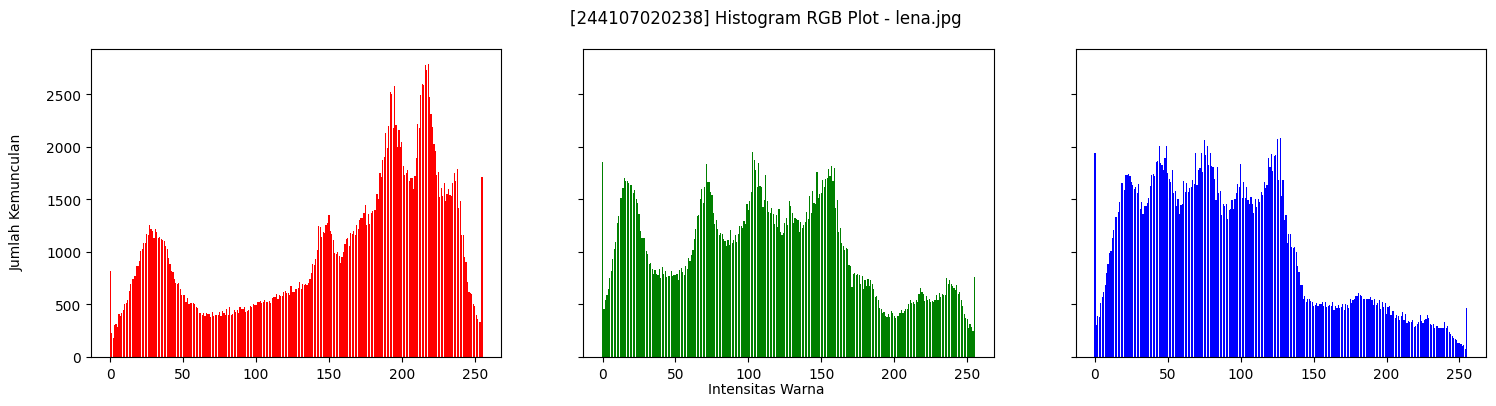

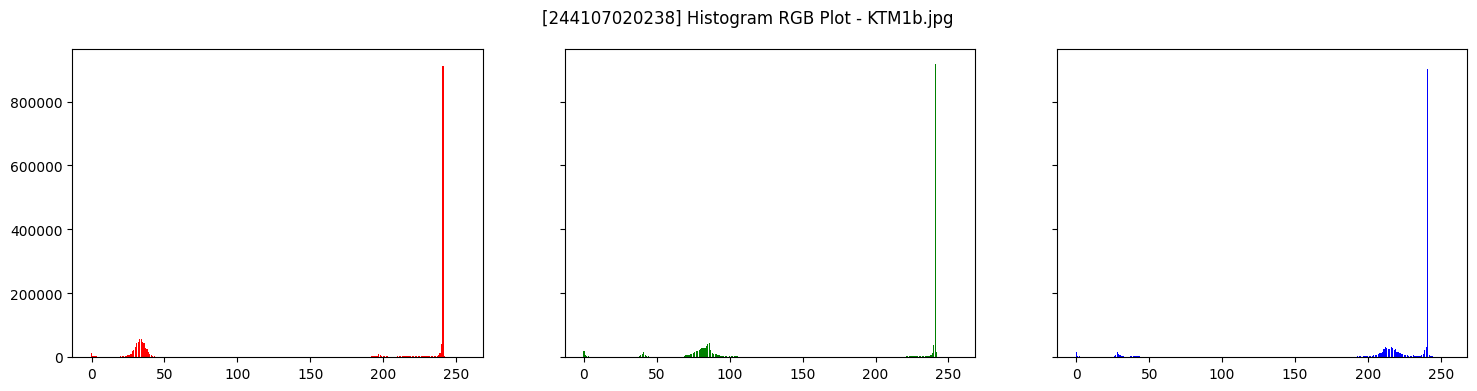

In [20]:
def hitung_histogram_manual_rgb(img_rgb):
    height, width, _ = img_rgb.shape
    names = np.arange(256)

    red   = [0] * 256
    green = [0] * 256
    blue  = [0] * 256

    for y in range(height):
        for x in range(width):
            red[img_rgb[y, x, 0]]   += 1
            green[img_rgb[y, x, 1]] += 1
            blue[img_rgb[y, x, 2]]  += 1

    return names, red, green, blue

# --- Tahap 1: Verifikasi Citra Contoh (lena.jpg) ---
img_lena = cv.imread(CONTOH + '/lena.jpg')
img_lena_rgb = cv.cvtColor(img_lena, cv.COLOR_BGR2RGB)

names, red, green, blue = hitung_histogram_manual_rgb(img_lena_rgb)

fig, axs = plt.subplots(1, 3, figsize=(18, 4), sharex=True, sharey=True)
fig.suptitle(f'[{NIM}] Histogram RGB Plot - lena.jpg')
fig.text(0.08, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.02, 'Intensitas Warna', ha='center')

axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

# --- Tahap 2: Citra Pribadi (KTM1b.jpg) ---
img_ktm1b = cv.imread(BASE + '/KTM1b.jpg')
if img_ktm1b is not None:
    img_ktm1b_rgb = cv.cvtColor(img_ktm1b, cv.COLOR_BGR2RGB)
    names, r, g, b = hitung_histogram_manual_rgb(img_ktm1b_rgb)

    fig, axs = plt.subplots(1, 3, figsize=(18, 4), sharex=True, sharey=True)
    fig.suptitle(f'[{NIM}] Histogram RGB Plot - KTM1b.jpg')
    axs[0].bar(names, r, color='red')
    axs[1].bar(names, g, color='green')
    axs[2].bar(names, b, color='blue')
    plt.show()
else:
    print(f"Peringatan: File KTM1b.jpg belum ada di folder {BASE}")

### Pertanyaan Praktikum E1 - Soal 1: Verifikasi Ketepatan Perhitungan Histogram
*Menghitung histogram menggunakan 3 metode (Manual, `numpy.histogram`, dan `cv.calcHist`) serta memverifikasi bahwa selisih maksimum di antara ketiganya bernilai nol.*

In [21]:
def verifikasi_histogram(img_gray, title_name):
    # 1. Perhitungan Manual
    h_manual = np.zeros(256, dtype=np.int64)
    for y in range(img_gray.shape[0]):
        for x in range(img_gray.shape[1]):
            h_manual[img_gray[y, x]] += 1

    # 2. NumPy
    h_numpy, _ = np.histogram(img_gray.ravel(), bins=256, range=[0, 256])

    # 3. OpenCV
    h_cv = cv.calcHist([img_gray], [0], None, [256], [0, 256]).ravel().astype(np.int64)

    # Selisih Maksimum
    diff_manual_np = np.max(np.abs(h_manual - h_numpy))
    diff_manual_cv = np.max(np.abs(h_manual - h_cv))
    diff_np_cv     = np.max(np.abs(h_numpy - h_cv))

    print(f"=== Hasil Verifikasi Histogram ({title_name}) ===")
    print(f"Selisih Maksimum (Manual vs NumPy) : {diff_manual_np}")
    print(f"Selisih Maksimum (Manual vs OpenCV): {diff_manual_cv}")
    print(f"Selisih Maksimum (NumPy vs OpenCV) : {diff_np_cv}")
    assert diff_manual_np == 0 and diff_manual_cv == 0, "Error: Histogram tidak identik!"
    print("KESIMPULAN: BERHASIL TERVERIFIKASI (Selisih Tepat 0)\n")

# Verifikasi pada lena.jpg
gray_lena = cv.imread(CONTOH + '/lena.jpg', cv.IMREAD_GRAYSCALE)
verifikasi_histogram(gray_lena, "lena.jpg")

# Verifikasi pada KTM1b.jpg
gray_ktm1b = cv.imread(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)
if gray_ktm1b is not None:
    verifikasi_histogram(gray_ktm1b, "KTM1b.jpg")

=== Hasil Verifikasi Histogram (lena.jpg) ===
Selisih Maksimum (Manual vs NumPy) : 0
Selisih Maksimum (Manual vs OpenCV): 0
Selisih Maksimum (NumPy vs OpenCV) : 0
KESIMPULAN: BERHASIL TERVERIFIKASI (Selisih Tepat 0)

=== Hasil Verifikasi Histogram (KTM1b.jpg) ===
Selisih Maksimum (Manual vs NumPy) : 0
Selisih Maksimum (Manual vs OpenCV): 0
Selisih Maksimum (NumPy vs OpenCV) : 0
KESIMPULAN: BERHASIL TERVERIFIKASI (Selisih Tepat 0)



### Pertanyaan Praktikum E1 - Soal 2: Kurva PDF dan CDF Citra Pribadi
*Menampilkan Histogram Ternormalisasi $p(j)$ (PDF) dan Kurva Distribusi Kumulatif (CDF) untuk seluruh variasi pencahayaan citra KTM (KTM1a.jpg - KTM1d.jpg).*

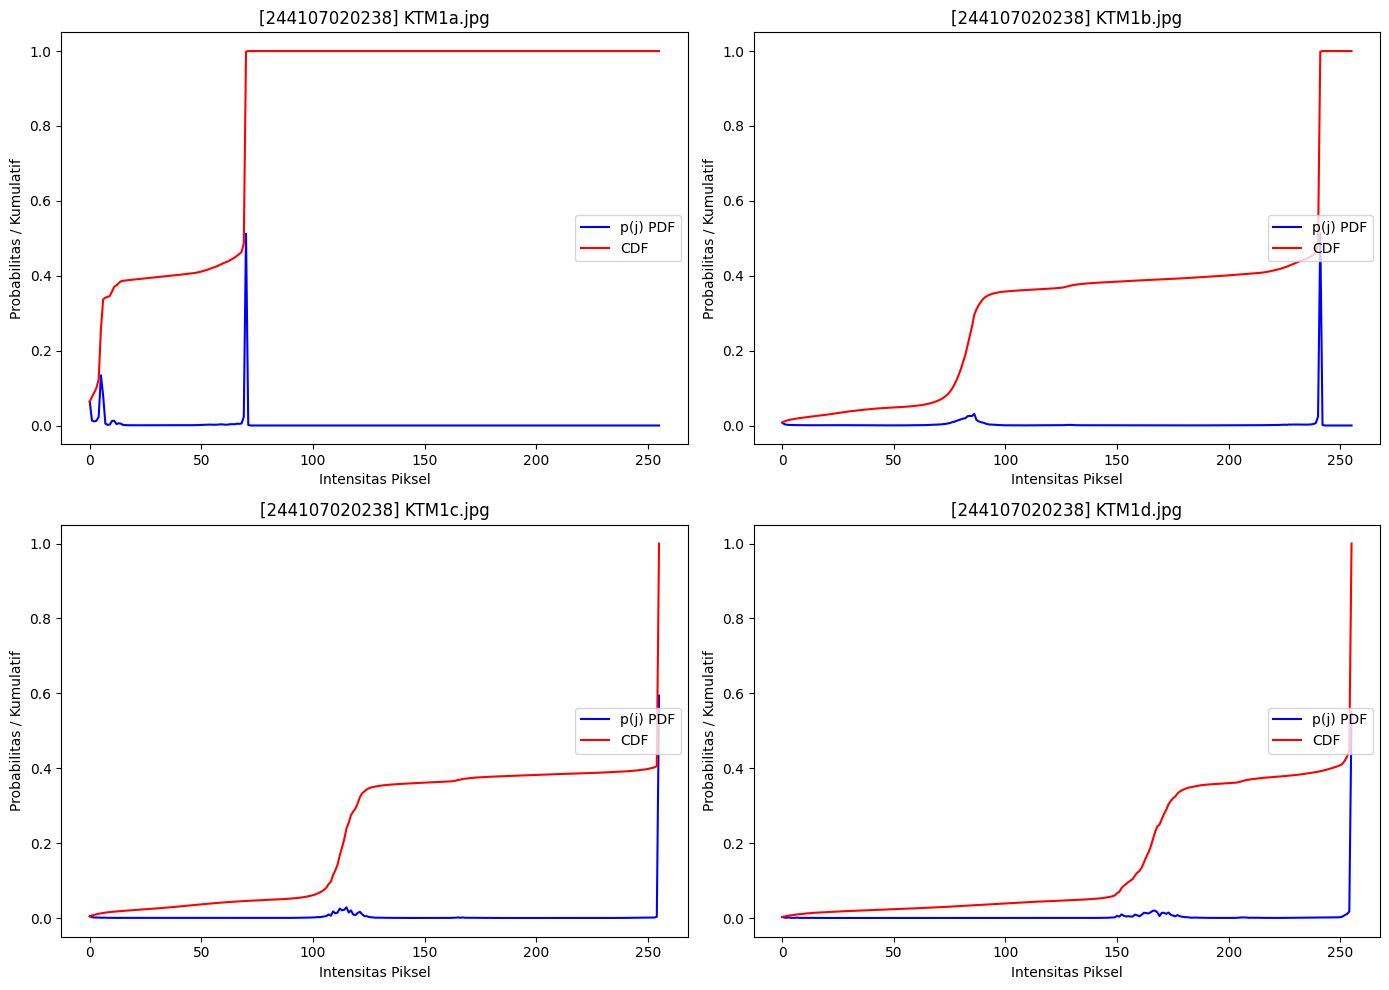

In [22]:
files = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.ravel()

for idx, fname in enumerate(files):
    path = os.path.join(BASE, fname)
    if not os.path.exists(path):
        continue
    img = cv.imread(path, cv.IMREAD_GRAYSCALE)

    # PDF (Probability Density Function)
    p = cv.calcHist([img], [0], None, [256], [0, 256]).ravel() / img.size
    # CDF (Cumulative Distribution Function)
    cdf = np.cumsum(p)

    axs[idx].plot(p, color='blue', label='p(j) PDF')
    axs[idx].plot(cdf, color='red', label='CDF')
    axs[idx].set_title(f'[{NIM}] {fname}')
    axs[idx].legend(loc='center right')
    axs[idx].set_xlabel('Intensitas Piksel')
    axs[idx].set_ylabel('Probabilitas / Kumulatif')

plt.tight_layout()
plt.show()

> **Pembahasan Analisis Kurva CDF**:
> 1. **KTM1a.jpg (Ruangan Gelap / *Underexposed*)**: Kurva CDF naik secara sangat curam pada rentang intensitas rendah ($0 - 50$). Hal ini mencerminkan dominasi piksel gelap akibat pencahayaan yang sangat minim.
> 2. **KTM1d.jpg (Sinar Matahari / *Overexposed*)**: Kurva CDF tetap landai pada intensitas rendah, namun melesat tajam pada rentang intensitas tinggi ($180 - 255$). Hal ini menunjukkan sebagian besar area gambar terisi oleh piksel dengan intensitas terang tinggi.

### Pertanyaan Praktikum E1 - Soal 3: Pengaruh Variasi Jumlah Bin Histogram
*Membandingkan histogram citra KTM1b.jpg dengan jumlah bin bawaan `PARAM['bins']` dan 256 bin.*

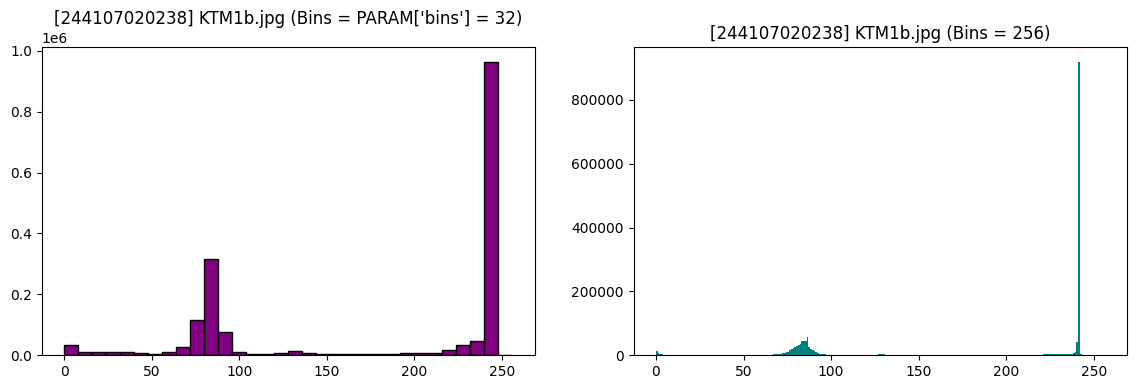

In [23]:
if gray_ktm1b is not None:
    num_bins = PARAM['bins']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    # Bins Kustom dari PARAM
    ax1.hist(gray_ktm1b.ravel(), bins=num_bins, range=[0, 256], color='purple', edgecolor='black')
    ax1.set_title(f'[{NIM}] KTM1b.jpg (Bins = PARAM[\'bins\'] = {num_bins})')

    # Bins Penuh (256)
    ax2.hist(gray_ktm1b.ravel(), bins=256, range=[0, 256], color='teal')
    ax2.set_title(f'[{NIM}] KTM1b.jpg (Bins = 256)')

    plt.show()

> **Pembahasan Pengurangan Jumlah Bin**:
> Pengurangan jumlah bin (misalnya menjadi $8$, $16$, atau $32$) mengakibatkan terjadinya **kuantisasi intensitas piksel**. Informasi detail mengenai variasi nilai keabuan yang halus (*fine detail*) menjadi hilang karena beberapa derajat keabuan yang berdekatan dikelompokkan ke dalam satu grup bin yang sama.

---
## E-2 PERCOBAAN HISTOGRAM EQUALIZATION (HE)

### Konsep Teori:
Ekualisasi Histogram bertujuan untuk mendistribusikan ulang intensitas piksel agar lebih merata di seluruh rentang skala keabuan ($0 - 255$). Persamaan perataan menggunakan fungsi transformasi CDF:
$$s_k = T(r_k) = (L-1) \sum_{j=0}^{k} p_r(r_j)$$

Selisih Maksimum Manual vs equalizeHist (lena_lc.jpg): 0


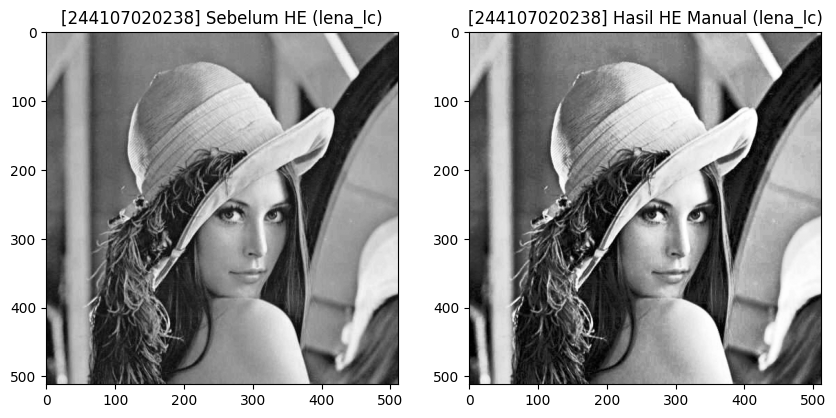

Selisih Maksimum Manual vs equalizeHist (KTM1a.jpg): 16


In [24]:
def manual_histogram_equalization(img_gray):
    # 1. Hitung Frekuensi
    hist, _ = np.histogram(img_gray.ravel(), bins=256, range=[0, 256])
    # 2. Hitung CDF
    cdf = hist.cumsum()
    # 3. Normalisasi CDF
    cdf_normalized = cdf / cdf[-1]
    # 4. Fungsi Transformasi S_k
    transform_map = np.round(cdf_normalized * 255).astype(np.uint8)
    # 5. Pemetaan Piksel
    img_equalized = transform_map[img_gray]
    return img_equalized

# --- Tahap 1: Citra Contoh (lena_lc.jpg) ---
img_lc = cv.imread(CONTOH + '/lena_lc.jpg', cv.IMREAD_GRAYSCALE)
he_manual_lc = manual_histogram_equalization(img_lc)
he_cv_lc     = cv.equalizeHist(img_lc)

diff_lc = np.max(np.abs(he_manual_lc.astype(np.int16) - he_cv_lc.astype(np.int16)))
print(f"Selisih Maksimum Manual vs equalizeHist (lena_lc.jpg): {diff_lc}")

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img_lc, cmap='gray')
axs[0].set_title(f'[{NIM}] Sebelum HE (lena_lc)')
axs[1].imshow(he_manual_lc, cmap='gray')
axs[1].set_title(f'[{NIM}] Hasil HE Manual (lena_lc)')
plt.show()

# --- Tahap 2: Citra Gelap Pribadi (KTM1a.jpg) ---
img_ktm1a_gray = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)
if img_ktm1a_gray is not None:
    he_manual_ktm = manual_histogram_equalization(img_ktm1a_gray)
    he_cv_ktm     = cv.equalizeHist(img_ktm1a_gray)
    diff_ktm      = np.max(np.abs(he_manual_ktm.astype(np.int16) - he_cv_ktm.astype(np.int16)))
    print(f"Selisih Maksimum Manual vs equalizeHist (KTM1a.jpg): {diff_ktm}")

### E-2 Langkah 3 & 4: Ekualisasi Citra Berwarna dan Analisis Pergeseran Hue
Perbandingan ekualisasi warna dengan 2 pendekatan:
1. **Cara 1:** Mengekualisasi setiap kanal warna B, G, R secara terpisah.
2. **Cara 2:** Mengekualisasi hanya kanal kecerahan/intensitas ($Y$ pada YCrCb, $V$ pada HSV, dan $L$ pada LAB).

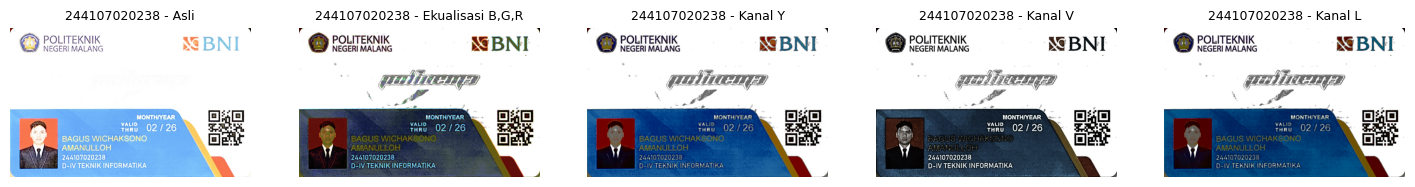


=== Tabel Evaluasi Ekualisasi Warna (KTM1d.jpg) ===
Cara Ekualisasi        Rerata Pergeseran Hue (°)     Rerata Kecerahan
--------------------------------------------------------------------
Asli                                     0.00                216.2
Ekualisasi B,G,R                        12.69                167.1
Kanal Y                                  1.45                167.3
Kanal V                                  1.09                164.4
Kanal L                                  3.03                163.7


In [25]:
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d  = np.abs(h1 - h2)
    d  = np.minimum(d, 180 - d) # Sifat melingkar nilai Hue (0-179)
    return d.mean()

def evaluasi_ekualisasi_warna(bgr_img, img_name):
    # Cara 1: Ekualisasi B, G, R terpisah
    kanal = list(cv.split(bgr_img))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_rgb = cv.merge(kanal)

    # Cara 2: YCrCb (Kanal Y)
    ycrcb = cv.cvtColor(bgr_img, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    # Varian HSV (Kanal V)
    hsv = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)
    h, sat, v = cv.split(hsv)
    he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

    # Varian LAB (Kanal L)
    lab = cv.cvtColor(bgr_img, cv.COLOR_BGR2LAB)
    l, a, b = cv.split(lab)
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

    judul = ['Asli', 'Ekualisasi B,G,R', 'Kanal Y', 'Kanal V', 'Kanal L']
    citra = [bgr_img, he_rgb, he_y, he_v, he_l]

    # Visualisasi
    plt.figure(figsize=(18, 4))
    for i, (c, t) in enumerate(zip(citra, judul), 1):
        plt.subplot(1, 5, i)
        plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
        plt.title(f"{NIM} - {t}", fontsize=9)
        plt.axis('off')
    plt.show()

    # Tabel Evaluasi
    print(f"\n=== Tabel Evaluasi Ekualisasi Warna ({img_name}) ===")
    print('%-22s %22s %20s' % ('Cara Ekualisasi', 'Rerata Pergeseran Hue (°)', 'Rerata Kecerahan'))
    print('-' * 68)
    for t, c in zip(judul, citra):
        shift = geser_hue(bgr_img, c) * 2  # Konversi ke skala 360 derajat
        bright = cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
        print('%-22s %22.2f %20.1f' % (t, shift, bright))

bgr_ktm1d = cv.imread(BASE + '/KTM1d.jpg')
if bgr_ktm1d is not None:
    evaluasi_ekualisasi_warna(bgr_ktm1d, "KTM1d.jpg")

### Jawaban Pertanyaan Evaluasi Ekualisasi Warna (E-2):

1. **Cara dengan Pergeseran Hue Terbesar**: Ekualisasi independen kanal **B, G, R** menghasilkan pergeseran Hue paling besar. Hal ini terjadi karena proses perataan histogram merusak rasio keseimbangan warna dasar antara kanal B, G, dan R.
2. **Penyebab Pergeseran Hue pada Kanal Terang Tidak Nol**: Meskipun hanya kanal luminansi/kecerahan ($Y/V/L$) yang diekualisasi, transformasi kembali ke ruang warna BGR melibatkan pembulatan nilai desimal dan pemotongan (*clipping*) pada rentang $[0, 255]$.
3. **Kanal Terbaik untuk Foto KTM**: Kanal **L (Ruang Warna LAB)** atau **Y (Ruang Warna YCrCb)** paling sesuai karena mampu meningkatkan kontras teks tanpa merusak keaslian warna identitas pada kartu.

### Pertanyaan Praktikum E2.1: Analisis PSNR Ekualisasi Global
*Menerapkan ekualisasi histogram pada KTM1a.jpg (grayscale) dan mengukur skor Peak Signal-to-Noise Ratio (PSNR).*

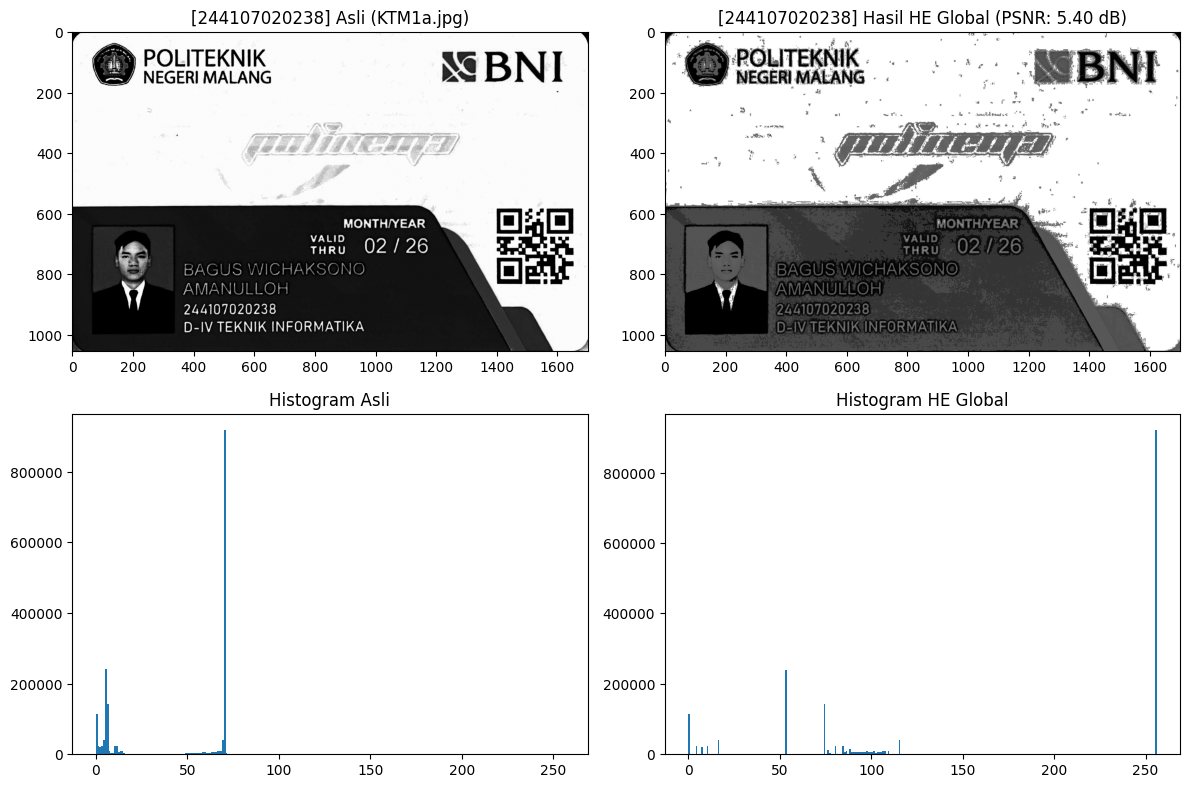

In [26]:
def hitung_psnr(orig, proc):
    mse = np.mean((orig.astype(np.float64) - proc.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse))

if img_ktm1a_gray is not None:
    ktm_he = cv.equalizeHist(img_ktm1a_gray)
    psnr_val = hitung_psnr(img_ktm1a_gray, ktm_he)

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    axs[0, 0].imshow(img_ktm1a_gray, cmap='gray')
    axs[0, 0].set_title(f'[{NIM}] Asli (KTM1a.jpg)')

    axs[0, 1].imshow(ktm_he, cmap='gray')
    axs[0, 1].set_title(f'[{NIM}] Hasil HE Global (PSNR: {psnr_val:.2f} dB)')

    axs[1, 0].hist(img_ktm1a_gray.ravel(), bins=256, range=[0, 256])
    axs[1, 0].set_title('Histogram Asli')

    axs[1, 1].hist(ktm_he.ravel(), bins=256, range=[0, 256])
    axs[1, 1].set_title('Histogram HE Global')

    plt.tight_layout()
    plt.show()

> **Pembahasan PSNR**:
> - **Mengapa Nilai PSNR Turun?** Nilai PSNR dihitung berdasarkan *Mean Squared Error* (MSE) perbedaan piksel secara langsung antara citra asli dan citra olahan. Karena ekualisasi histogram meregangkan kontras secara intensif, selisih matematis piksel menjadi besar sehingga skor PSNR menurun secara signifikan.
> - **Kelayakan PSNR**: PSNR **tidak layak** digunakan sebagai tolok ukur tunggal untuk menilai tingkat keterbacaan (*readability*) suatu citra, karena PSNR mengukur fidelitas piksel mutlak, bukan tingkat kejelasan visual atau kontras lokal.

### Pertanyaan Praktikum E2.2: Ekualisasi Lokal (CLAHE)
*Menerapkan CLAHE pada KTM1a.jpg menggunakan parameter `PARAM['clip']` dan `PARAM['tile']` serta menguji pengaruh variasi nilai `clipLimit`.*

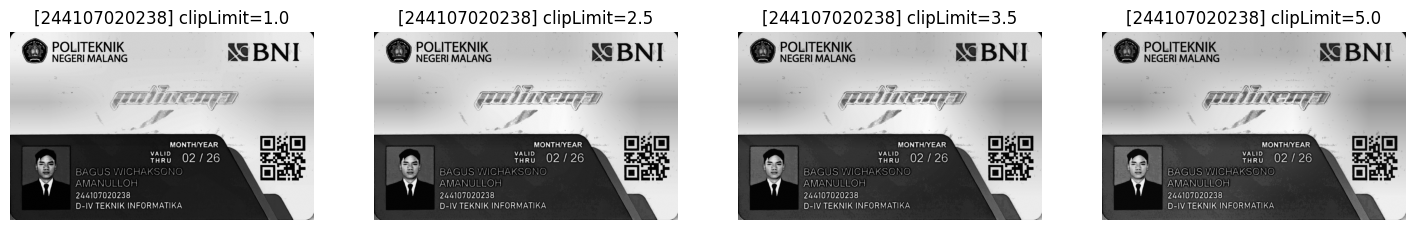

In [27]:
if img_ktm1a_gray is not None:
    clip_base = PARAM['clip']
    tile_base = PARAM['tile']

    # Pengujian beberapa variasi clipLimit
    clip_tests = [1.0, clip_base, clip_base + 1.0, 5.0]
    fig, axs = plt.subplots(1, 4, figsize=(18, 4))

    for i, c_val in enumerate(clip_tests):
        c_obj = cv.createCLAHE(clipLimit=c_val, tileGridSize=(tile_base, tile_base))
        res = c_obj.apply(img_ktm1a_gray)
        axs[i].imshow(res, cmap='gray')
        axs[i].set_title(f'[{NIM}] clipLimit={c_val}')
        axs[i].axis('off')

    plt.show()

> **Pembahasan CLAHE**:
> - **Keterbacaan Detail**: Teks Nama dan NIM pada KTM terlihat jauh lebih jelas pada hasil **CLAHE** dibandingkan ekualisasi global. Ekualisasi global menyebabkan area yang terang mengalami *over-saturation*, sedangkan CLAHE membatasi pembesaran kontras hanya pada wilayah blok lokal (*tiles*).
> - **Dampak `clipLimit` Tinggi**: Ketika `clipLimit` dinaikkan secara berlebihan (misal $5.0$), *noise* bintik-bintik (*grain*) pada latar belakang kartu ikut teramplifikasi sehingga mengganggu kualitas visual.

---
## E-3 TUGAS PRAKTIKUM DITHERING (ERROR DIFFUSION)

### Konsep Teori:
Dithering dengan teknik *Error Diffusion* Floyd-Steinberg mendistribusikan kesalahan kuantisasi (*quantization error*) dari piksel yang sedang diproses ke piksel-piksel tetangganya yang belum diproses dengan bobot kernel:
$$\frac{1}{16} \begin{bmatrix} - & \# & 7 \\ 3 & 5 & 1 \end{bmatrix}$$

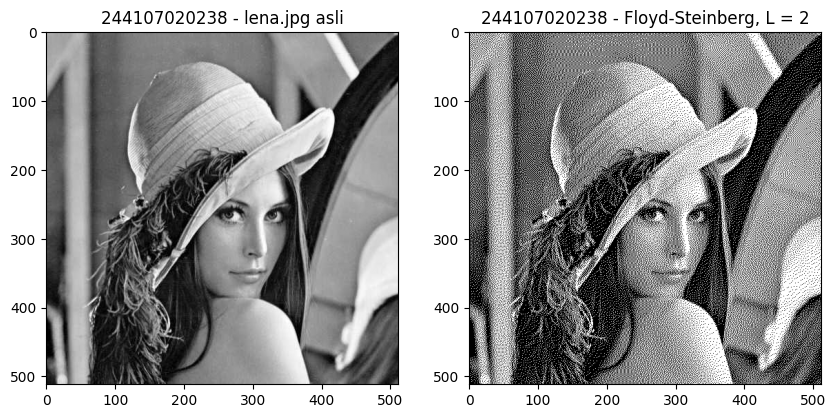

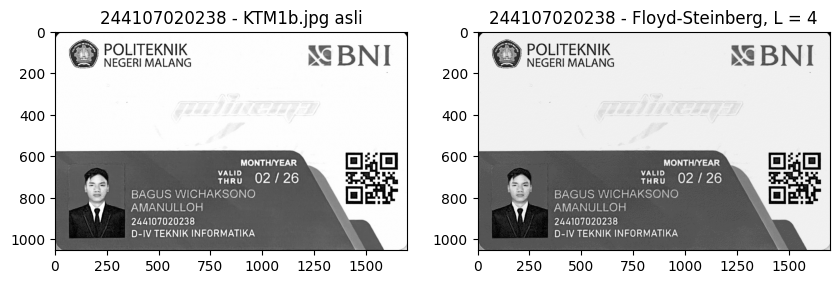

In [28]:
def floyd_steinberg(gray_img, L=2):
    img = gray_img.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape

    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru

            # Distribusi eror ke 4 tetangga sesuai konvensi sumbu
            if x + 1 < W:
                img[y, x + 1] += error * (7.0 / 16.0)
            if x > 0 and y + 1 < H:
                img[y + 1, x - 1] += error * (3.0 / 16.0)
            if y + 1 < H:
                img[y + 1, x] += error * (5.0 / 16.0)
            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += error * (1.0 / 16.0)

    return np.clip(img, 0, 255).astype(np.uint8)

# --- Tahap 1: Verifikasi pada lena.jpg (L = 2) ---
gray_lena = cv.imread(CONTOH + '/lena.jpg', cv.IMREAD_GRAYSCALE)
dither_lena = floyd_steinberg(gray_lena, L=2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(gray_lena, cmap='gray')
ax1.set_title(f'{NIM} - lena.jpg asli')
ax2.imshow(dither_lena, cmap='gray')
ax2.set_title(f'{NIM} - Floyd-Steinberg, L = 2')
plt.show()

# --- Tahap 2: Penerapan pada KTM1b.jpg (L = PARAM['L']) ---
if gray_ktm1b is not None:
    level_l = PARAM['L']
    dither_ktm = floyd_steinberg(gray_ktm1b, L=level_l)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    ax1.imshow(gray_ktm1b, cmap='gray')
    ax1.set_title(f'{NIM} - KTM1b.jpg asli')
    ax2.imshow(dither_ktm, cmap='gray')
    ax2.set_title(f'{NIM} - Floyd-Steinberg, L = {level_l}')
    plt.show()

### E-3 Langkah 2: Analisis Urutan Ekualisasi dan Dithering
Membandingkan dua skenario pengerjaan:
1. **Dithering Langsung** tanpa perbaikan kontras.
2. **Ekualisasi Histogram terlebih dahulu**, baru kemudian dijalankan proses **Dithering**.

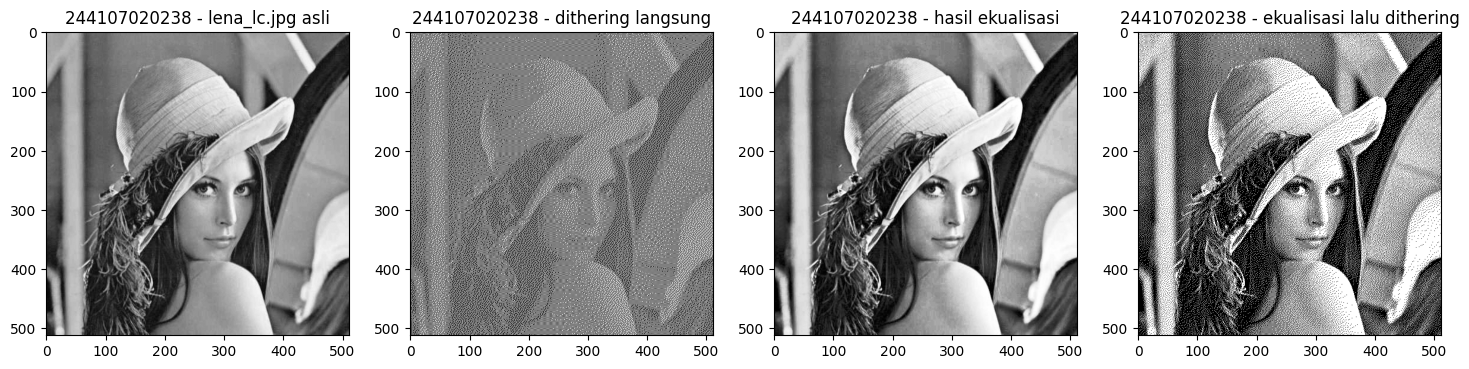

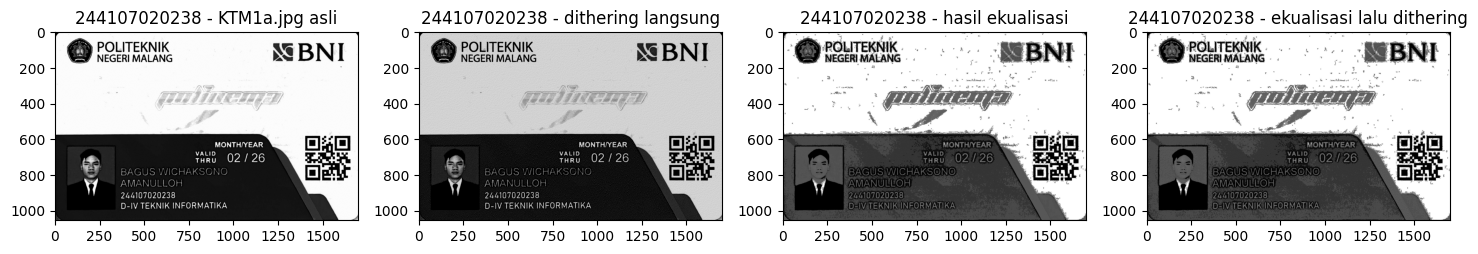

In [29]:
# --- Tahap 1: lena_lc.jpg ---
img_lc = cv.imread(CONTOH + '/lena_lc.jpg', cv.IMREAD_GRAYSCALE)
dither_direct_lc = floyd_steinberg(img_lc, L=2)
he_lc = cv.equalizeHist(img_lc)
dither_he_lc = floyd_steinberg(he_lc, L=2)

fig, axs = plt.subplots(1, 4, figsize=(18, 4))
axs[0].imshow(img_lc, cmap='gray')
axs[0].set_title(f'{NIM} - lena_lc.jpg asli')
axs[1].imshow(dither_direct_lc, cmap='gray')
axs[1].set_title(f'{NIM} - dithering langsung')
axs[2].imshow(he_lc, cmap='gray')
axs[2].set_title(f'{NIM} - hasil ekualisasi')
axs[3].imshow(dither_he_lc, cmap='gray')
axs[3].set_title(f'{NIM} - ekualisasi lalu dithering')
plt.show()

# --- Tahap 2: KTM1a.jpg ---
if img_ktm1a_gray is not None:
    dither_direct_ktm = floyd_steinberg(img_ktm1a_gray, L=PARAM['L'])
    he_ktm = cv.equalizeHist(img_ktm1a_gray)
    dither_he_ktm = floyd_steinberg(he_ktm, L=PARAM['L'])

    fig, axs = plt.subplots(1, 4, figsize=(18, 4))
    axs[0].imshow(img_ktm1a_gray, cmap='gray')
    axs[0].set_title(f'{NIM} - KTM1a.jpg asli')
    axs[1].imshow(dither_direct_ktm, cmap='gray')
    axs[1].set_title(f'{NIM} - dithering langsung')
    axs[2].imshow(he_ktm, cmap='gray')
    axs[2].set_title(f'{NIM} - hasil ekualisasi')
    axs[3].imshow(dither_he_ktm, cmap='gray')
    axs[3].set_title(f'{NIM} - ekualisasi lalu dithering')
    plt.show()

---
## KESIMPULAN PRAKTIKUM

1. **Histogram Citra**: Berhasil membuktikan bahwa hasil kalkulasi histogram manual (per iterasi piksel) bernilai sama persis dengan fungsi teroptimasi `numpy.histogram` dan `cv.calcHist` (selisih maksimum 0).
2. **Kondisi Pencahayaan Citra**: Kurva CDF dari citra gelap (`KTM1a.jpg`) terakumulasi cepat pada intensitas rendah, sedangkan citra terang (`KTM1d.jpg`) menumpuk pada intensitas tinggi.
3. **Ekualisasi Citra Berwarna**: Mengekualisasi hanya kanal kecerahan ($L$ pada LAB / $Y$ pada YCrCb) terbukti efektif meningkatkan kontras tanpa merusak warna (*minim pergeseran Hue*), berbanding terbalik dengan ekualisasi terpisah pada kanal B, G, R yang merusak keseimbangan warna.
4. **CLAHE vs Global HE**: CLAHE memberikan keterbacaan teks (Nama dan NIM) yang jauh lebih tinggi pada citra terdistorsi cahaya lokal karena terhindar dari *over-saturation*.
5. **Urutan Dithering**: Pada citra dengan pencahayaan rendah, urutan **Ekualisasi Histogram terlebih dahulu sebelum Dithering** terbukti mutlak diperlukan agar informasi teks tidak hilang saat proses pengurangan level kedalaman warna.